In [ ]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import numpy as np
import re


# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define data paths
BASE_DIR = Path("data/MultiTaskVideoReasoning")
MTVR_COT_DIR = BASE_DIR / "MTVR_CoT"
MTVR_TOOL_COT_DIR = BASE_DIR / "MTVR_Tool_CoT"

print("✅ Imports successful!")
print(f"📂 Base directory: {BASE_DIR}")


✅ Imports successful!
📂 Base directory: data/MultiTaskVideoReasoning
✅ Imports successful!
📂 Base directory: data/MultiTaskVideoReasoning


In [13]:
mtvr_cot_data.keys()

dict_keys(['Video-R1-data-video', 'longvideo-reason', 'charades', 'actnet', 'Video-R1-data-image', 'rextime', 'nextgqa', 'vidchapters'])

In [17]:
mtvr_cot_data['Video-R1-data-video'][0].keys()

dict_keys(['id', 'text', 'solution', 'video', 'duration'])

In [10]:
# Load all MTVR_CoT datasets
def load_json_file(filepath):
    """Load a JSON file and return its contents."""
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

# Load MTVR_CoT data
mtvr_cot_data = {}
for json_file in MTVR_COT_DIR.glob("*.json"):
    dataset_name = json_file.stem
    data = load_json_file(json_file)
    mtvr_cot_data[dataset_name] = data
    print(f"📊 Loaded {dataset_name}: {len(data)} samples")

# Load MTVR_Tool_CoT data
mtvr_tool_cot_data = {}
for json_file in MTVR_TOOL_COT_DIR.glob("*.json"):
    dataset_name = json_file.stem
    data = load_json_file(json_file)
    mtvr_tool_cot_data[dataset_name] = data
    print(f"🛠️ Loaded Tool-CoT {dataset_name}: {len(data)} samples")

print(f"\n✅ Total MTVR_CoT datasets: {len(mtvr_cot_data)}")
print(f"✅ Total MTVR_Tool_CoT datasets: {len(mtvr_tool_cot_data)}")


📊 Loaded Video-R1-data-video: 6993 samples
📊 Loaded longvideo-reason: 7626 samples
📊 Loaded charades: 10608 samples
📊 Loaded actnet: 9494 samples
📊 Loaded Video-R1-data-image: 8065 samples
📊 Loaded rextime: 3666 samples
📊 Loaded nextgqa: 3021 samples
📊 Loaded vidchapters: 4257 samples
🛠️ Loaded Tool-CoT longvideo-reason: 7019 samples
🛠️ Loaded Tool-CoT vidchapters: 10571 samples

✅ Total MTVR_CoT datasets: 8
✅ Total MTVR_Tool_CoT datasets: 2


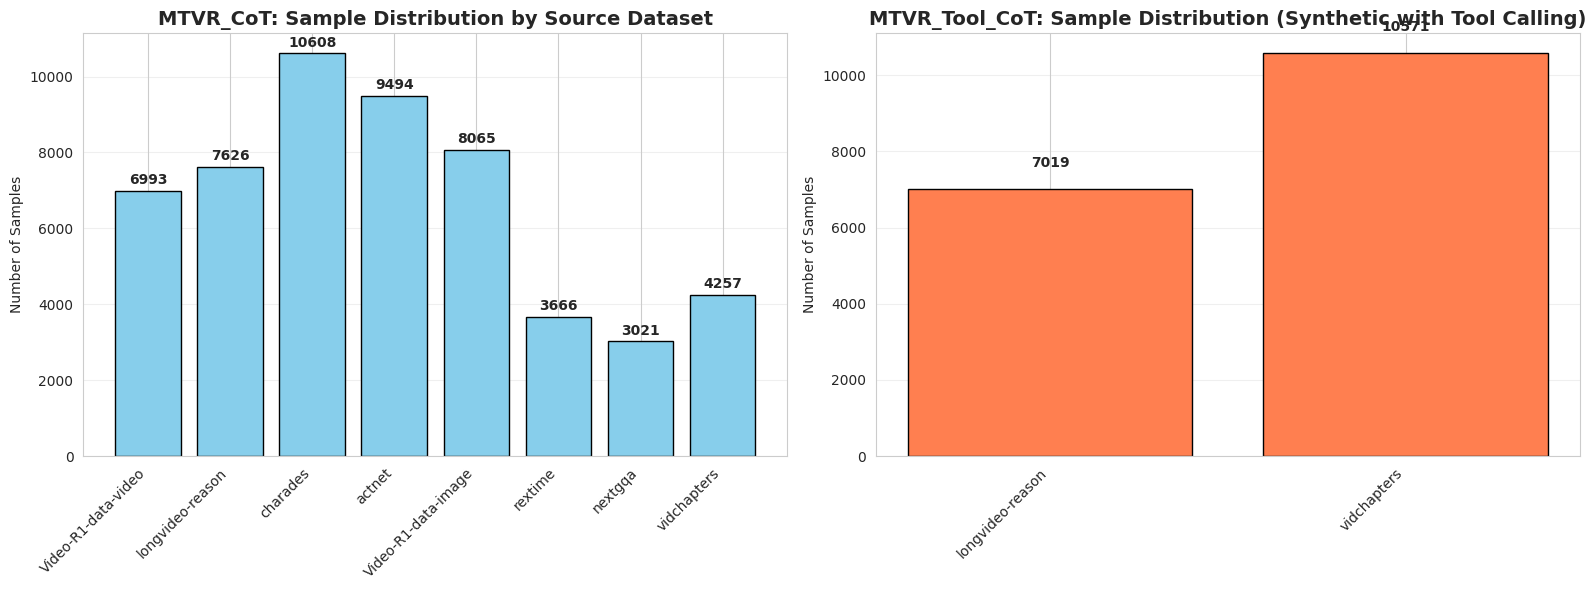


📈 DATASET SIZE SUMMARY
Total MTVR_CoT samples: 53,730
Total MTVR_Tool_CoT samples: 17,590
Grand Total: 71,320


In [ ]:
# Visualization 1: Distribution of samples across source datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MTVR_CoT distribution
cot_counts = {k: len(v) for k, v in mtvr_cot_data.items()}
axes[0].bar(range(len(cot_counts)), list(cot_counts.values()), color='skyblue', edgecolor='black')
axes[0].set_xticks(range(len(cot_counts)))
axes[0].set_xticklabels(list(cot_counts.keys()), rotation=45, ha='right')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('MTVR_CoT: Sample Distribution by Source Dataset', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(cot_counts.values()):
    axes[0].text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')

# MTVR_Tool_CoT distribution
tool_cot_counts = {k: len(v) for k, v in mtvr_tool_cot_data.items()}
axes[1].bar(range(len(tool_cot_counts)), list(tool_cot_counts.values()), color='coral', edgecolor='black')
axes[1].set_xticks(range(len(tool_cot_counts)))
axes[1].set_xticklabels(list(tool_cot_counts.keys()), rotation=45, ha='right')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('MTVR_Tool_CoT: Sample Distribution (Synthetic with Tool Calling)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(tool_cot_counts.values()):
    axes[1].text(i, v + 500, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("📈 DATASET SIZE SUMMARY")
print("="*60)
print(f"Total MTVR_CoT samples: {sum(cot_counts.values()):,}")
print(f"Total MTVR_Tool_CoT samples: {sum(tool_cot_counts.values()):,}")
print(f"Grand Total: {sum(cot_counts.values()) + sum(tool_cot_counts.values()):,}")
print("="*60)

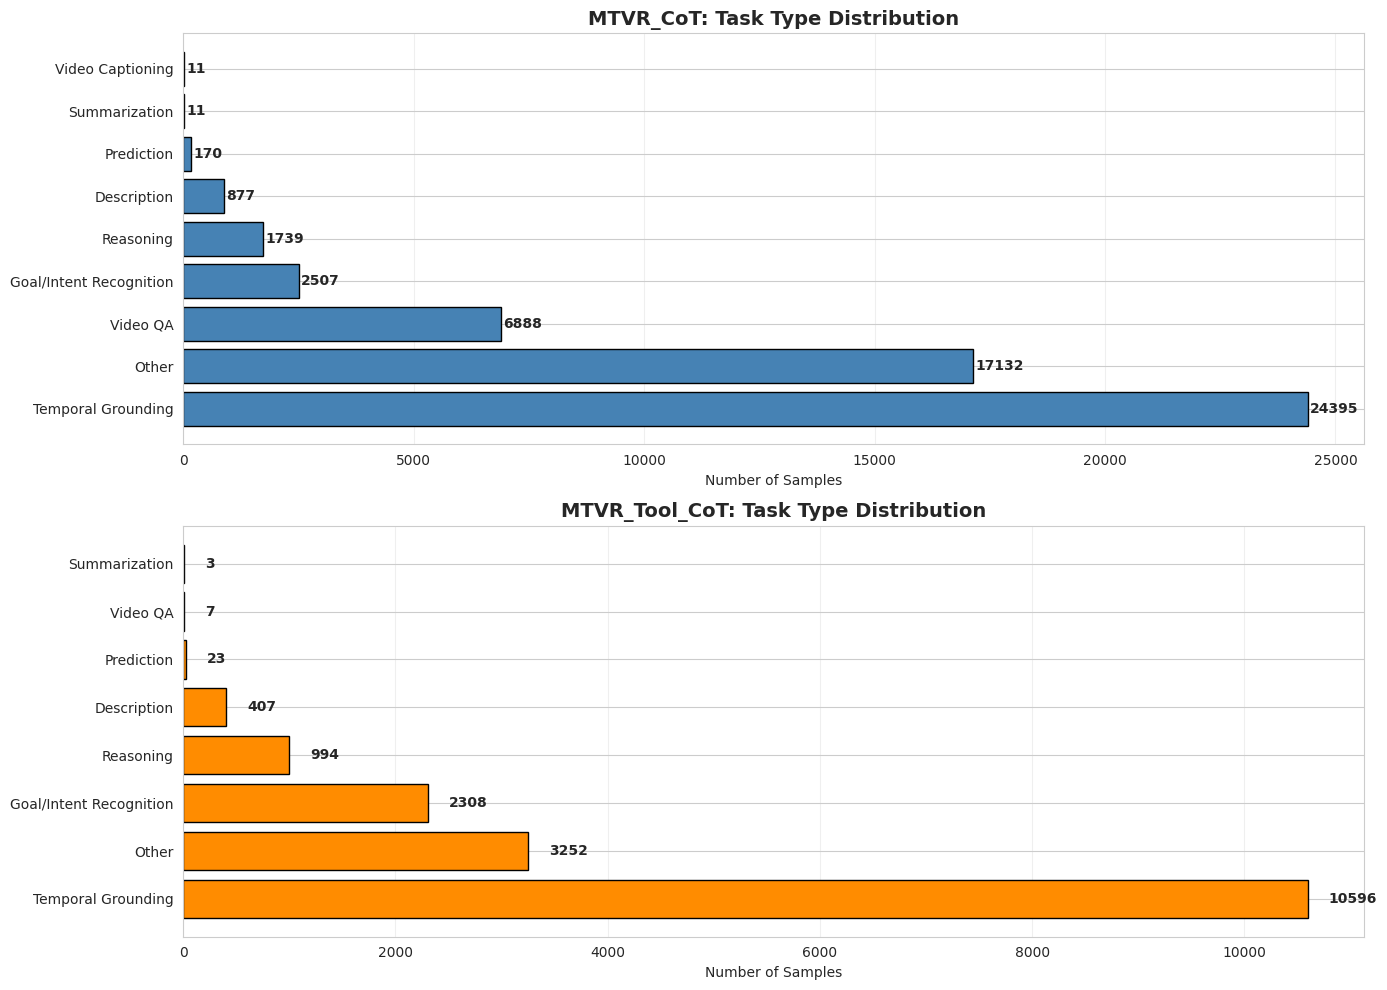


🎯 TASK TYPE BREAKDOWN

MTVR_CoT:
task_type
Temporal Grounding         24395
Other                      17132
Video QA                    6888
Goal/Intent Recognition     2507
Reasoning                   1739
Description                  877
Prediction                   170
Summarization                 11
Video Captioning              11
Name: count, dtype: int64

MTVR_Tool_CoT:
task_type
Temporal Grounding         10596
Other                       3252
Goal/Intent Recognition     2308
Reasoning                    994
Description                  407
Prediction                    23
Video QA                       7
Summarization                  3
Name: count, dtype: int64


In [3]:
# Visualization 2: Task Type Analysis
# Extract task types from the text field

def extract_task_type(text):
    """Extract task type from the instruction text."""
    text_lower = text.lower()
    
    # Define task patterns
    if 'temporal' in text_lower or 'starting and ending times' in text_lower or 'start time and end time' in text_lower:
        return 'Temporal Grounding'
    elif 'caption' in text_lower:
        return 'Video Captioning'
    elif 'question' in text_lower and 'answer' in text_lower:
        return 'Video QA'
    elif 'summarize' in text_lower or 'summary' in text_lower:
        return 'Summarization'
    elif 'reasoning' in text_lower or 'inferred' in text_lower or 'why' in text_lower:
        return 'Reasoning'
    elif 'describe' in text_lower:
        return 'Description'
    elif 'predict' in text_lower or 'what will' in text_lower:
        return 'Prediction'
    elif 'goal' in text_lower or 'intention' in text_lower or 'purpose' in text_lower:
        return 'Goal/Intent Recognition'
    else:
        return 'Other'

# Analyze task types in MTVR_CoT
task_types_cot = []
for dataset_name, data in mtvr_cot_data.items():
    for sample in data:
        task_type = extract_task_type(sample.get('text', ''))
        task_types_cot.append({'dataset': dataset_name, 'task_type': task_type})

df_tasks_cot = pd.DataFrame(task_types_cot)

# Analyze task types in MTVR_Tool_CoT
task_types_tool = []
for dataset_name, data in mtvr_tool_cot_data.items():
    for sample in data:
        task_type = extract_task_type(sample.get('text', ''))
        task_types_tool.append({'dataset': dataset_name, 'task_type': task_type})

df_tasks_tool = pd.DataFrame(task_types_tool)

# Create visualizations
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Task type distribution in MTVR_CoT
task_counts_cot = df_tasks_cot['task_type'].value_counts()
axes[0].barh(range(len(task_counts_cot)), task_counts_cot.values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(task_counts_cot)))
axes[0].set_yticklabels(task_counts_cot.index)
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('MTVR_CoT: Task Type Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(task_counts_cot.values):
    axes[0].text(v + 50, i, str(v), va='center', fontweight='bold')

# Task type distribution in MTVR_Tool_CoT
task_counts_tool = df_tasks_tool['task_type'].value_counts()
axes[1].barh(range(len(task_counts_tool)), task_counts_tool.values, color='darkorange', edgecolor='black')
axes[1].set_yticks(range(len(task_counts_tool)))
axes[1].set_yticklabels(task_counts_tool.index)
axes[1].set_xlabel('Number of Samples')
axes[1].set_title('MTVR_Tool_CoT: Task Type Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, v in enumerate(task_counts_tool.values):
    axes[1].text(v + 200, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🎯 TASK TYPE BREAKDOWN")
print("="*60)
print("\nMTVR_CoT:")
print(task_counts_cot)
print("\nMTVR_Tool_CoT:")
print(task_counts_tool)
print("="*60)


/tmp/ipykernel_2291461/3229085628.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_durations_cot, x='dataset', y='duration', ax=axes[0], palette='Set2')
/tmp/ipykernel_2291461/3229085628.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_durations_tool, x='dataset', y='duration', ax=axes[1], palette='Set1')


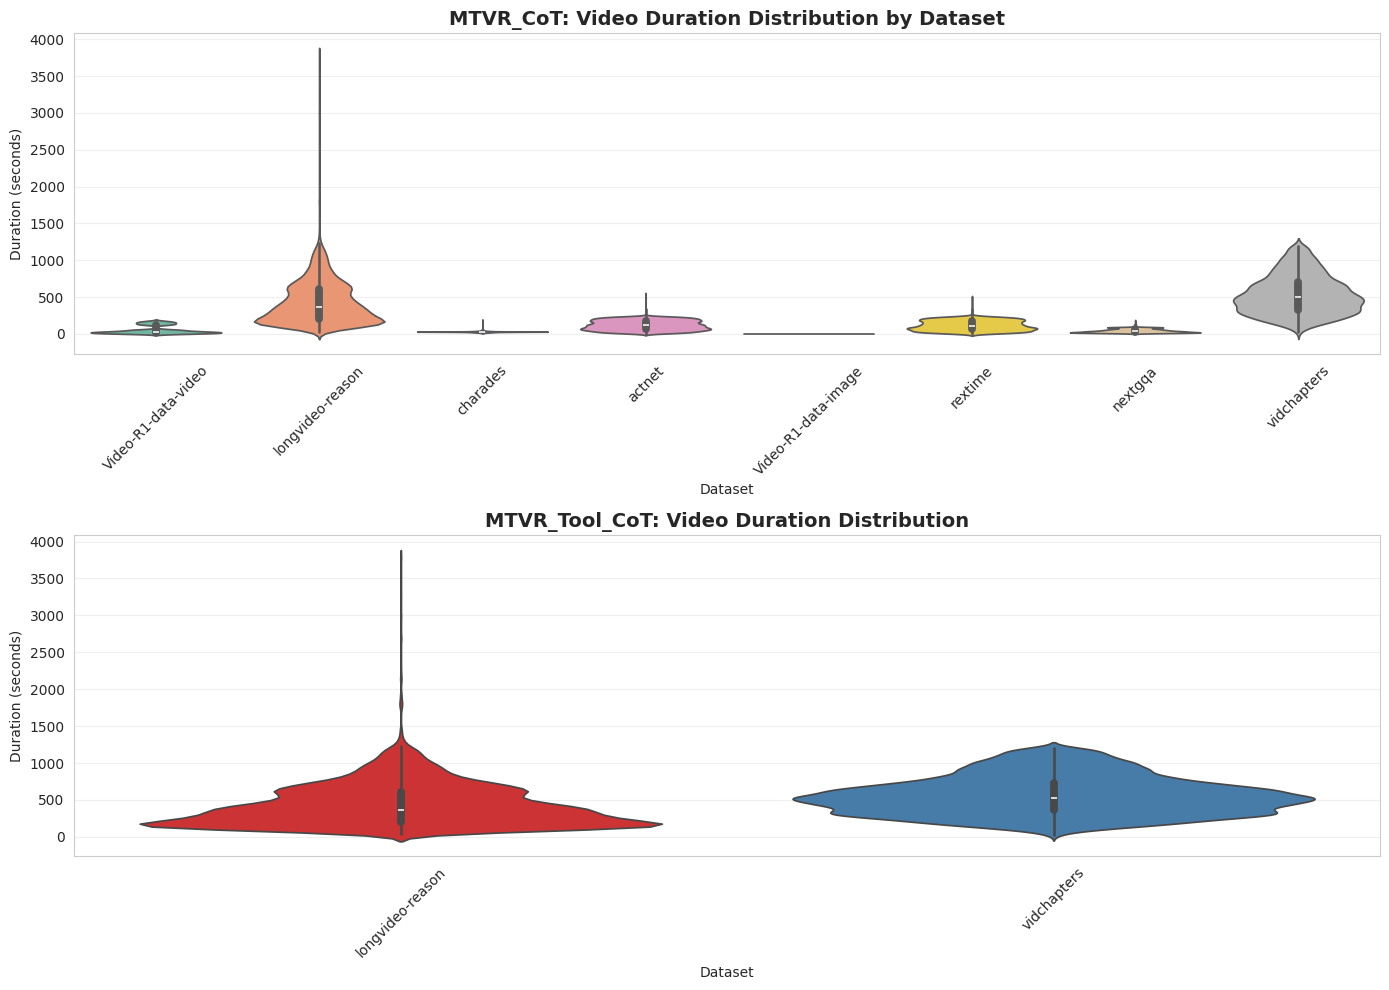


⏱️ VIDEO DURATION STATISTICS

MTVR_CoT:
                       count        mean         std    min       25%  \
dataset                                                                 
Video-R1-data-image   8065.0    0.000000    0.000000   0.00    0.0000   
Video-R1-data-video   6993.0   59.325254   56.051397   5.00   17.5000   
actnet                9494.0  120.921072   65.433026   2.56   65.6700   
charades             10608.0   31.291819    9.271381   5.53   28.4400   
longvideo-reason      7626.0  434.935084  299.448788  28.79  198.8050   
nextgqa               3021.0   43.352863   24.995456  10.00   22.0000   
rextime               3666.0  116.890900   67.003270   1.58   60.3425   
vidchapters           4257.0  537.828283  262.784372  32.00  328.0000   

                         50%       75%      max  
dataset                                          
Video-R1-data-image    0.000    0.0000     0.00  
Video-R1-data-video   32.500  123.5000   180.00  
actnet               117.890

In [4]:
# Visualization 3: Video Duration Analysis
durations_cot = []
for dataset_name, data in mtvr_cot_data.items():
    for sample in data:
        if 'duration' in sample:
            durations_cot.append({
                'dataset': dataset_name,
                'duration': sample['duration']
            })

df_durations_cot = pd.DataFrame(durations_cot)

durations_tool = []
for dataset_name, data in mtvr_tool_cot_data.items():
    for sample in data:
        if 'duration' in sample:
            durations_tool.append({
                'dataset': dataset_name,
                'duration': sample['duration']
            })

df_durations_tool = pd.DataFrame(durations_tool)

# Create violin plots for duration distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# MTVR_CoT duration distribution
if not df_durations_cot.empty:
    sns.violinplot(data=df_durations_cot, x='dataset', y='duration', ax=axes[0], palette='Set2')
    axes[0].set_title('MTVR_CoT: Video Duration Distribution by Dataset', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Dataset')
    axes[0].set_ylabel('Duration (seconds)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)

# MTVR_Tool_CoT duration distribution
if not df_durations_tool.empty:
    sns.violinplot(data=df_durations_tool, x='dataset', y='duration', ax=axes[1], palette='Set1')
    axes[1].set_title('MTVR_Tool_CoT: Video Duration Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Dataset')
    axes[1].set_ylabel('Duration (seconds)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("⏱️ VIDEO DURATION STATISTICS")
print("="*60)
if not df_durations_cot.empty:
    print("\nMTVR_CoT:")
    print(df_durations_cot.groupby('dataset')['duration'].describe())
if not df_durations_tool.empty:
    print("\nMTVR_Tool_CoT:")
    print(df_durations_tool.groupby('dataset')['duration'].describe())
print("="*60)


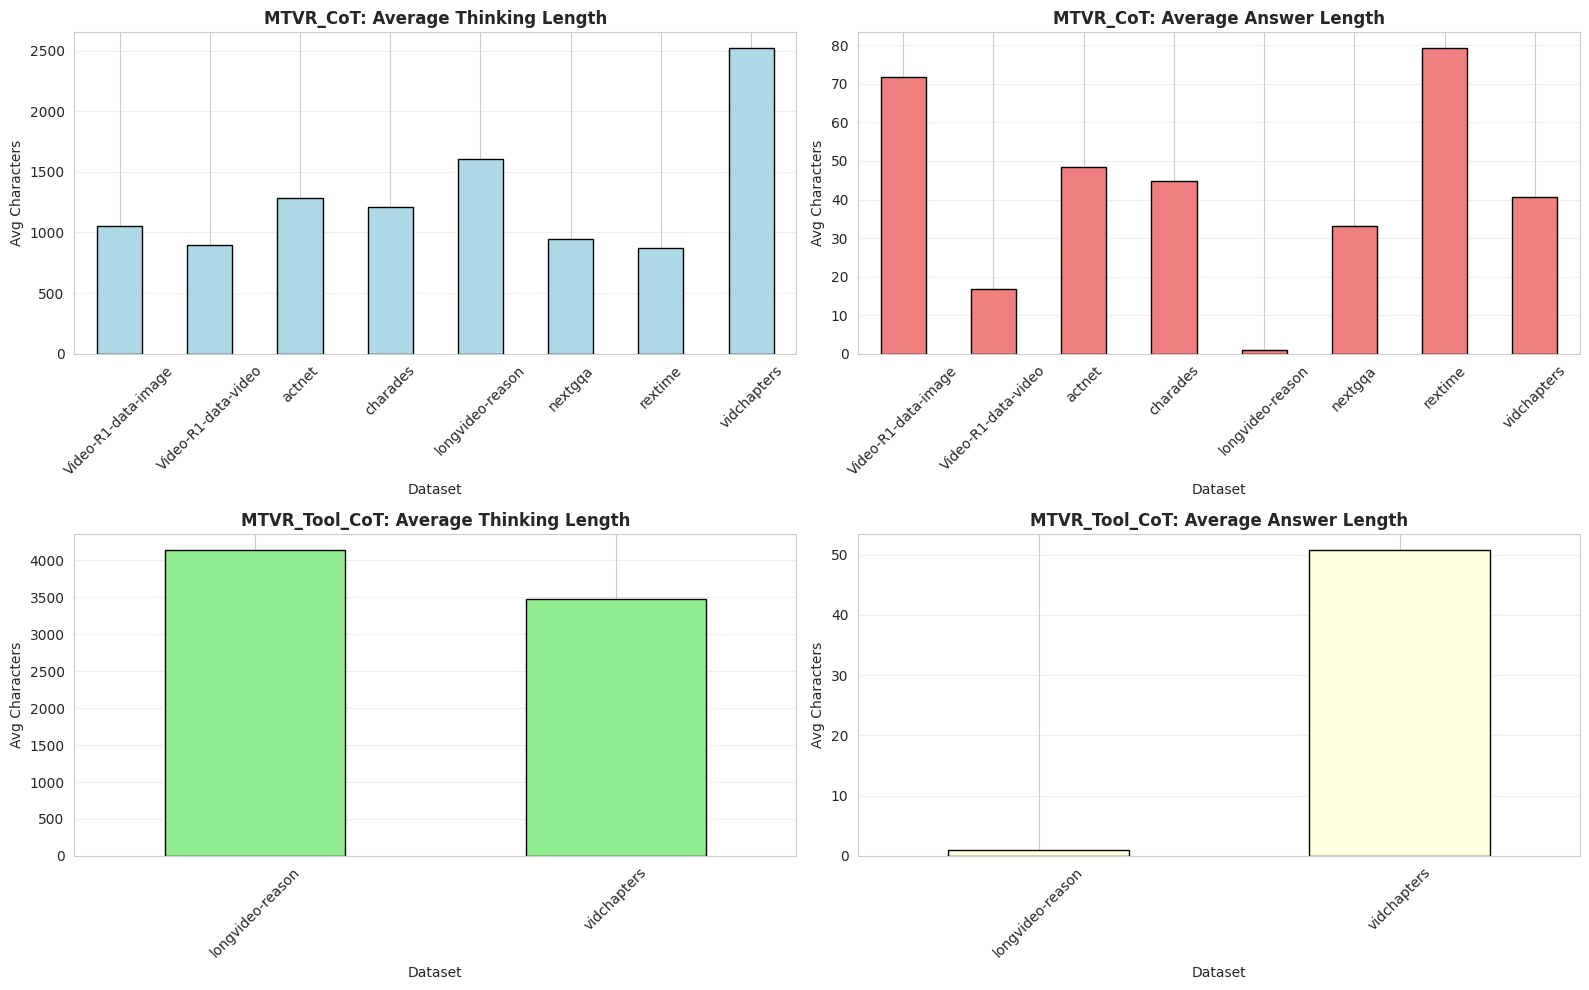


📝 SOLUTION LENGTH STATISTICS

MTVR_CoT - Average lengths:
                     think_length  answer_length  total_length
dataset                                                       
Video-R1-data-image   1055.769994      71.684811   1127.454805
Video-R1-data-video    898.024453      16.698842    914.723295
actnet                1283.066779      48.321045   1331.387824
charades              1206.977470      44.762066   1251.739536
longvideo-reason      1608.274325       1.000000   1609.274325
nextgqa                944.939424      33.177756    978.117180
rextime                868.061648      79.397163    947.458811
vidchapters           2524.583744      40.627202   2565.210947

MTVR_Tool_CoT - Average lengths:
                  think_length  answer_length  total_length
dataset                                                    
longvideo-reason   4144.472574       1.000285   4145.472859
vidchapters        3480.926592      50.784505   3531.711096


In [5]:
# Visualization 4: Solution Length Analysis (thinking + answer)
def extract_thinking_and_answer(solution):
    """Extract thinking and answer parts from solution."""
    if isinstance(solution, str):
        think_match = re.search(r'<think>(.*?)</think>', solution, re.DOTALL)
        answer_match = re.search(r'<answer>(.*?)</answer>', solution, re.DOTALL)
        
        think_len = len(think_match.group(1).strip()) if think_match else 0
        answer_len = len(answer_match.group(1).strip()) if answer_match else 0
        
        return think_len, answer_len
    elif isinstance(solution, list):
        # For Tool_CoT data, solution is a list
        total_think = 0
        total_answer = 0
        for item in solution:
            think_len, answer_len = extract_thinking_and_answer(item)
            total_think += think_len
            total_answer += answer_len
        return total_think, total_answer
    return 0, 0

# Analyze solution lengths
solution_stats_cot = []
for dataset_name, data in mtvr_cot_data.items():
    for sample in data:
        think_len, answer_len = extract_thinking_and_answer(sample.get('solution', ''))
        solution_stats_cot.append({
            'dataset': dataset_name,
            'think_length': think_len,
            'answer_length': answer_len,
            'total_length': think_len + answer_len
        })

df_solution_cot = pd.DataFrame(solution_stats_cot)

solution_stats_tool = []
for dataset_name, data in mtvr_tool_cot_data.items():
    for sample in data:
        think_len, answer_len = extract_thinking_and_answer(sample.get('solution', []))
        solution_stats_tool.append({
            'dataset': dataset_name,
            'think_length': think_len,
            'answer_length': answer_len,
            'total_length': think_len + answer_len
        })

df_solution_tool = pd.DataFrame(solution_stats_tool)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# CoT thinking length
df_solution_cot.groupby('dataset')['think_length'].mean().plot(kind='bar', ax=axes[0, 0], color='lightblue', edgecolor='black')
axes[0, 0].set_title('MTVR_CoT: Average Thinking Length', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Dataset')
axes[0, 0].set_ylabel('Avg Characters')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# CoT answer length
df_solution_cot.groupby('dataset')['answer_length'].mean().plot(kind='bar', ax=axes[0, 1], color='lightcoral', edgecolor='black')
axes[0, 1].set_title('MTVR_CoT: Average Answer Length', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Dataset')
axes[0, 1].set_ylabel('Avg Characters')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Tool_CoT thinking length
df_solution_tool.groupby('dataset')['think_length'].mean().plot(kind='bar', ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('MTVR_Tool_CoT: Average Thinking Length', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Dataset')
axes[1, 0].set_ylabel('Avg Characters')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Tool_CoT answer length
df_solution_tool.groupby('dataset')['answer_length'].mean().plot(kind='bar', ax=axes[1, 1], color='lightyellow', edgecolor='black')
axes[1, 1].set_title('MTVR_Tool_CoT: Average Answer Length', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Dataset')
axes[1, 1].set_ylabel('Avg Characters')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📝 SOLUTION LENGTH STATISTICS")
print("="*60)
print("\nMTVR_CoT - Average lengths:")
print(df_solution_cot.groupby('dataset')[['think_length', 'answer_length', 'total_length']].mean())
print("\nMTVR_Tool_CoT - Average lengths:")
print(df_solution_tool.groupby('dataset')[['think_length', 'answer_length', 'total_length']].mean())
print("="*60)


/tmp/ipykernel_2291461/3501399771.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tool_analysis, x='dataset', y='clip_duration', ax=axes[0], palette='pastel')
/tmp/ipykernel_2291461/3501399771.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tool_analysis, x='dataset', y='coverage_ratio', ax=axes[1], palette='pastel')


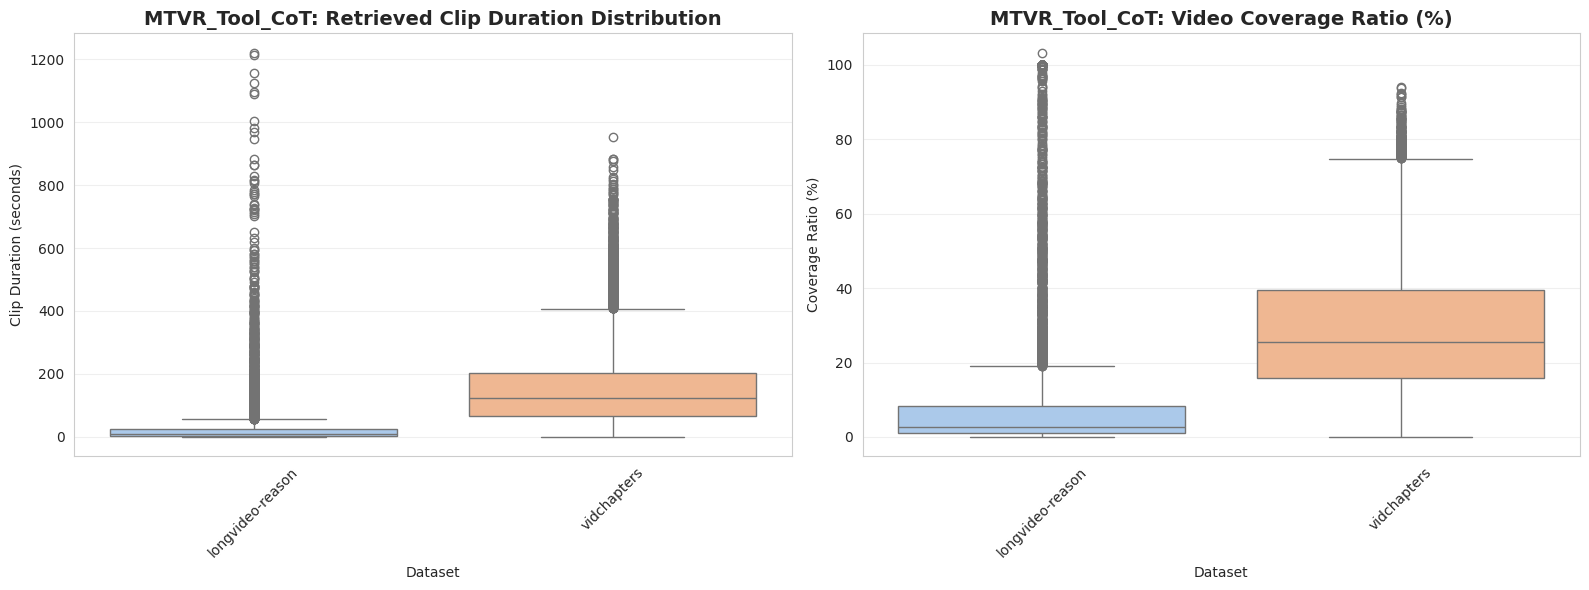


🛠️ TOOL CALLING STATISTICS

Retrieved Clip Statistics:
                 clip_duration                                             \
                         count        mean        std  min    25%     50%   
dataset                                                                     
longvideo-reason        7019.0   34.351542   87.37826  0.5   3.50   10.00   
vidchapters            10571.0  155.857818  131.27401  0.5  67.46  122.89   

                                   coverage_ratio                        \
                      75%      max          count       mean        std   
dataset                                                                   
longvideo-reason   25.000  1221.21         7019.0   9.673316  18.843462   
vidchapters       203.625   952.12        10571.0  28.744141  18.531018   

                                                                         
                       min        25%        50%        75%         max  
dataset                           

In [6]:
# Visualization 5: Tool Calling Analysis (MTVR_Tool_CoT specific)
def extract_tool_params(tool_params_str):
    """Extract start and end times from tool_params."""
    try:
        params = json.loads(tool_params_str)
        if isinstance(params, list) and len(params) == 2:
            return params[0], params[1]
    except:
        pass
    return None, None

tool_analysis = []
for dataset_name, data in mtvr_tool_cot_data.items():
    for sample in data:
        start_time, end_time = extract_tool_params(sample.get('tool_params', '[]'))
        if start_time is not None and end_time is not None:
            clip_duration = end_time - start_time
            total_duration = sample.get('duration', 0)
            coverage_ratio = clip_duration / total_duration if total_duration > 0 else 0
            
            tool_analysis.append({
                'dataset': dataset_name,
                'clip_duration': clip_duration,
                'total_duration': total_duration,
                'coverage_ratio': coverage_ratio * 100  # percentage
            })

df_tool_analysis = pd.DataFrame(tool_analysis)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clip duration distribution
if not df_tool_analysis.empty:
    sns.boxplot(data=df_tool_analysis, x='dataset', y='clip_duration', ax=axes[0], palette='pastel')
    axes[0].set_title('MTVR_Tool_CoT: Retrieved Clip Duration Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Dataset')
    axes[0].set_ylabel('Clip Duration (seconds)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Coverage ratio distribution
    sns.boxplot(data=df_tool_analysis, x='dataset', y='coverage_ratio', ax=axes[1], palette='pastel')
    axes[1].set_title('MTVR_Tool_CoT: Video Coverage Ratio (%)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Dataset')
    axes[1].set_ylabel('Coverage Ratio (%)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🛠️ TOOL CALLING STATISTICS")
print("="*60)
if not df_tool_analysis.empty:
    print("\nRetrieved Clip Statistics:")
    print(df_tool_analysis.groupby('dataset')[['clip_duration', 'coverage_ratio']].describe())
print("="*60)


NameError: name 'cot_counts' is not defined

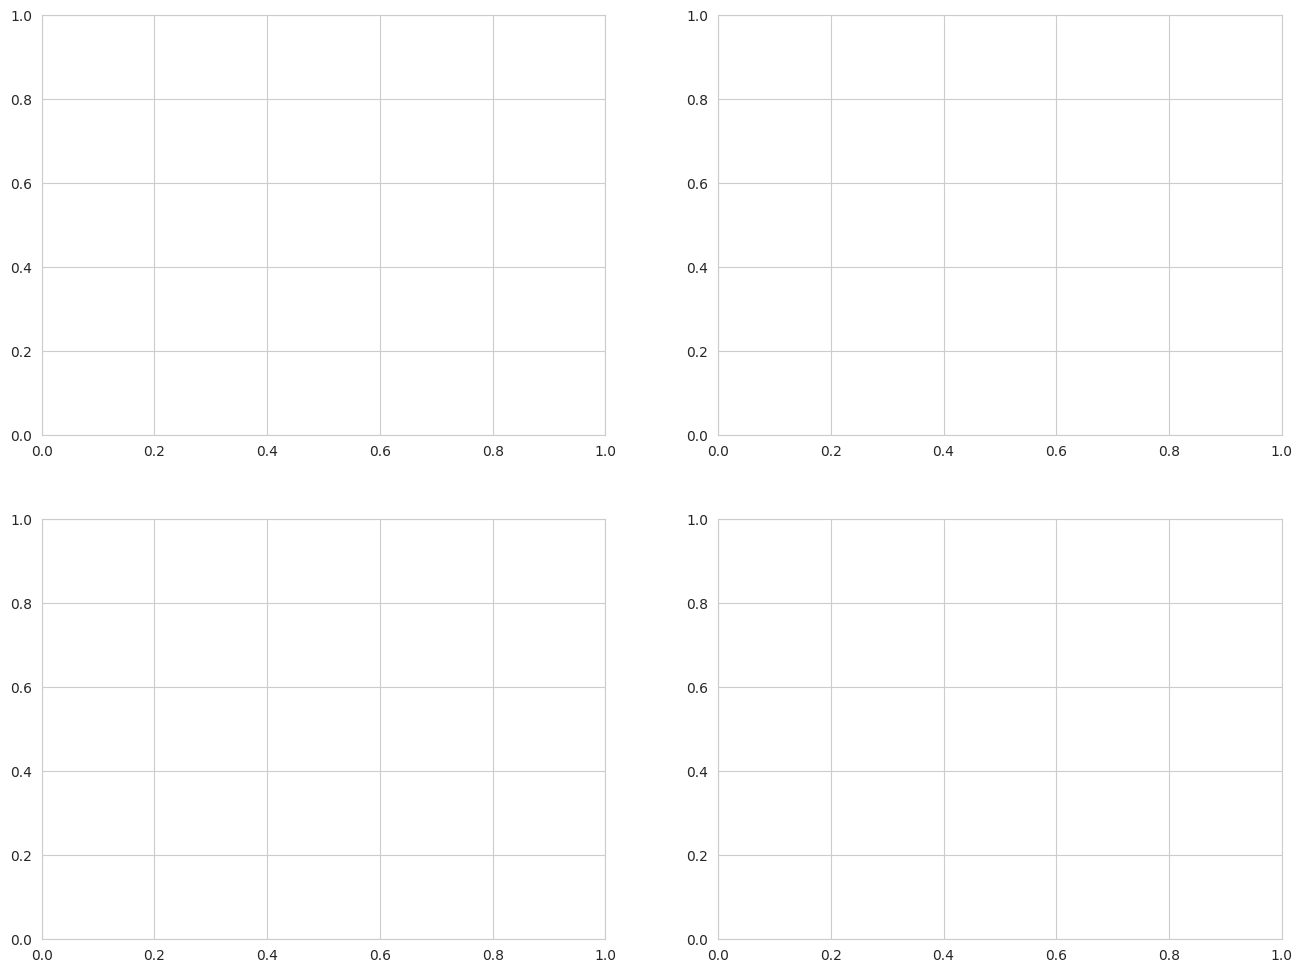

In [7]:
# Visualization 6: Comprehensive Dataset Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total samples comparison
datasets = ['MTVR_CoT', 'MTVR_Tool_CoT']
total_samples = [sum(cot_counts.values()), sum(tool_cot_counts.values())]
colors = ['skyblue', 'coral']

axes[0, 0].bar(datasets, total_samples, color=colors, edgecolor='black', width=0.6)
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_title('Total Samples Comparison', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(total_samples):
    axes[0, 0].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# 2. Average video duration
if not df_durations_cot.empty and not df_durations_tool.empty:
    avg_durations = [
        df_durations_cot['duration'].mean(),
        df_durations_tool['duration'].mean()
    ]
    axes[0, 1].bar(datasets, avg_durations, color=colors, edgecolor='black', width=0.6)
    axes[0, 1].set_ylabel('Seconds')
    axes[0, 1].set_title('Average Video Duration', fontsize=14, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(avg_durations):
        axes[0, 1].text(i, v + 5, f'{v:.1f}s', ha='center', va='bottom', fontweight='bold')

# 3. Average thinking length
avg_think = [
    df_solution_cot['think_length'].mean(),
    df_solution_tool['think_length'].mean()
]
axes[1, 0].bar(datasets, avg_think, color=colors, edgecolor='black', width=0.6)
axes[1, 0].set_ylabel('Characters')
axes[1, 0].set_title('Average Thinking Length', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_think):
    axes[1, 0].text(i, v + 50, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# 4. Average answer length
avg_answer = [
    df_solution_cot['answer_length'].mean(),
    df_solution_tool['answer_length'].mean()
]
axes[1, 1].bar(datasets, avg_answer, color=colors, edgecolor='black', width=0.6)
axes[1, 1].set_ylabel('Characters')
axes[1, 1].set_title('Average Answer Length', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_answer):
    axes[1, 1].text(i, v + 2, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Final comprehensive summary
print("\n" + "="*70)
print("📊 COMPREHENSIVE DATASET SUMMARY")
print("="*70)
print(f"\n{'Metric':<40} {'MTVR_CoT':<15} {'MTVR_Tool_CoT':<15}")
print("-"*70)
print(f"{'Total Samples':<40} {sum(cot_counts.values()):<15,} {sum(tool_cot_counts.values()):<15,}")
print(f"{'Number of Source Datasets':<40} {len(cot_counts):<15} {len(tool_cot_counts):<15}")
print(f"{'Avg Video Duration (seconds)':<40} {df_durations_cot['duration'].mean():<15.2f} {df_durations_tool['duration'].mean():<15.2f}")
print(f"{'Avg Thinking Length (chars)':<40} {df_solution_cot['think_length'].mean():<15.0f} {df_solution_tool['think_length'].mean():<15.0f}")
print(f"{'Avg Answer Length (chars)':<40} {df_solution_cot['answer_length'].mean():<15.0f} {df_solution_tool['answer_length'].mean():<15.0f}")
print(f"{'Avg Total Solution Length (chars)':<40} {df_solution_cot['total_length'].mean():<15.0f} {df_solution_tool['total_length'].mean():<15.0f}")
print("="*70)

print("\n💡 KEY INSIGHTS:")
print("   • MTVR_Tool_CoT is a synthetic dataset with tool-augmented reasoning")
print("   • Tool calling enables targeted frame retrieval for better reasoning")
print("   • Both datasets use <think> and <answer> tags for structured reasoning")
print("   • The data covers diverse video understanding tasks across multiple domains")
print("="*70)


In [8]:
# Bonus: Sample Data Exploration
print("="*70)
print("🔍 SAMPLE DATA EXAMPLES")
print("="*70)

# Show a sample from MTVR_CoT
print("\n" + "─"*70)
print("📄 MTVR_CoT Sample (actnet dataset):")
print("─"*70)
sample_cot = mtvr_cot_data['actnet'][0]
print(f"ID: {sample_cot['id']}")
print(f"Video: {sample_cot['video']}")
print(f"Duration: {sample_cot['duration']} seconds")
print(f"\nTask:\n{sample_cot['text'][:200]}...")
print(f"\nSolution structure:")
print(f"  - Has <think> tag: {'<think>' in sample_cot['solution']}")
print(f"  - Has <answer> tag: {'<answer>' in sample_cot['solution']}")
print(f"  - Total length: {len(sample_cot['solution'])} characters")

# Show a sample from MTVR_Tool_CoT
print("\n" + "─"*70)
print("🛠️ MTVR_Tool_CoT Sample (longvideo-reason dataset):")
print("─"*70)
sample_tool = mtvr_tool_cot_data['longvideo-reason'][0]
print(f"ID: {sample_tool['id']}")
print(f"Video: {sample_tool['video']}")
print(f"Duration: {sample_tool['duration']} seconds")
print(f"Tool Parameters: {sample_tool['tool_params']}")
print(f"\nTask:\n{sample_tool['text'][:200]}...")
print(f"\nSolution structure:")
print(f"  - Type: {type(sample_tool['solution'])}")
print(f"  - Number of reasoning steps: {len(sample_tool['solution'])}")
print(f"  - Has <tool_call> tag: {'<tool_call>' in str(sample_tool['solution'])}")

# Show video_kwargs
print(f"\nVideo kwargs:")
for key, value in sample_tool.get('video_kwargs', {}).items():
    print(f"  - {key}: {value}")

print("\n" + "="*70)
print("✅ Data analysis complete!")
print("="*70)


🔍 SAMPLE DATA EXAMPLES

──────────────────────────────────────────────────────────────────────
📄 MTVR_CoT Sample (actnet dataset):
──────────────────────────────────────────────────────────────────────
ID: 000000
Video: v_QOlSCBRmfWY.mp4
Duration: 82.73 seconds

Task:
Please find the visual event described by a sentence in the video, determining its starting and ending times. The format should be: 'The event happens in the start time - end time'. For example, The e...

Solution structure:
  - Has <think> tag: True
  - Has <answer> tag: True
  - Total length: 1548 characters

──────────────────────────────────────────────────────────────────────
🛠️ MTVR_Tool_CoT Sample (longvideo-reason dataset):
──────────────────────────────────────────────────────────────────────
ID: 000003
Video: JEnGmvnKggA.mp4
Duration: 403.52 seconds
Tool Parameters: [359.0, 394.0]

Task:
What is the primary goal of the person in the video, as inferred from the interaction dynamics, textual cues, and video compos

In [18]:
import pickle

with open("/data/user_data/jamesdin/data/vidchapters/tagged_video_ids.json", "rb") as f:
    all_data = pickle.load(f)

print(type(all_data))
print(len(all_data))


<class 'dict'>
817076


In [19]:
all_data['TdGLBI_lsig']

{'chapters': [{'label': 'Turbo and Cars', 'time': 40},
  {'label': 'Shrek and Monsters, Inc', 'time': 105},
  {'label': 'Madagascar and The Wild', 'time': 173},
  {'label': 'Home and Mars Needs Moms', 'time': 253},
  {'label': "The Road to El Dorado and The Emperor's New Groove", 'time': 320},
  {'label': 'Sinbad and Treasure Planet', 'time': 386},
  {'label': 'The Prince of Egypt and Mulan', 'time': 452},
  {'label': 'Flushed Away and Ratatouille', 'time': 522},
  {'label': "Antz and A Bug's Life", 'time': 595},
  {'label': 'Finding Nemo and Shark Tale', 'time': 655}],
 'duration': 746,
 'title': '10 Shocking Similarities Between Disney/Pixar And Dreamworks Films',
 'description': "10 Shocking Similarities Between Disney/Pixar And Dreamworks Films! Subscribe to our channel: http://goo.gl/ho3Hg6\n\nTry out ThePremium Network for free: https://goo.gl/URs6sk\n\nCheck Out These Other Amazing Videos:\n10 Times Disney Ripped Off Other Films - https://youtu.be/VhjDaCCyc50\n10 Popular Movie S

In [16]:
import json

with open("/data/user_data/jamesdin/data/vidchapters/train_video_ids.json", "rb") as f:
    train_data = json.load(f)

print(type(train_data))
print(len(train_data))

<class 'list'>
800676


In [ ]:
# load the vidchapters.json file

with open("data/MultiTaskVideoReasoning/MTVR_Tool_CoT/vidchapters.json") as f:
    train_data = json.load(f)

# all video ids are used in the training dataset. download all of them. To get the video ids, 
for example in train_data:
    vid = example['video_id'].split('.')[0]
    # download the video from youtube using yt-dlp
    # output path should be data/vidchapters/raw_videos/


with open("data/MultiTaskVideoReasoning/MTVR_Tool_CoT/vidchapters.json") as f:
    train_data = json.load(f)

# all video ids are used in the training dataset. download all of them. To get the video ids, 
downloaded = set()
for example in train_data:
    vid = example['video_id'].split('.')[0]
    if vid in downloaded:
        continue
    # download the video from youtube using yt-dlp
    # output path should be data/vidchapters/raw_videos/
    

with open("/data/user_data/jamesdin/data/vidchapters/val_video_ids.json", "rb") as f:
    val_video_ids = json.load(f)

with open("/data/user_data/jamesdin/data/vidchapters/test_video_ids.json", "rb") as f:
    test_video_ids = json.load(f)

for vid in val_video_ids + test_video_ids:
    if vid in downloaded:
        continue
    # download the video from youtube using yt-dlp
    # output path should be data/vidchapters/raw_videos/
    




10571

In [ ]:
val_video_ids '--5egaUoMpY'


True